# CVE Risk Classification — 03: Hybrid KNN + Decision Tree
**Imperial Business School Capstone | MSc Cybersecurity + AI/ML**  
**Author:** Eduardo Wizentier

## Core Contribution
A two-tier hybrid classifier where KNN acts as an **unsupervised feature engineer**,
discovering natural vulnerability clusters from behavioural signals (EPSS, CWE, CVE year),
then injecting a `cluster_id` feature into a Decision Tree — reducing majority-class bias
and improving classification under zero-day conditions.

## Architecture
```
CVE features (NVD + KEV + EPSS)
        ↓
   [TRAIN/TEST SPLIT]          ← split happens FIRST (no leakage)
        ↓
   KNN fitted on BEHAVIOURAL   ← EPSS + CWE + year only
   features (train only)          prevents cluster_id becoming
        ↓                          a severity proxy
   cluster_id appended to feature matrix
        ↓
   Decision Tree (depth=6, balanced) → severity classification
```

## Experiments
| # | Name | Features | Purpose |
|---|---|---|---|
| A | Standard Hybrid | CVSS components + cluster_id | Baseline |
| B | Zero-Day Blind | EPSS + KEV + CWE + era (no CVSS, no cluster) | Simulates missing scoring |
| C | Zero-Day Hybrid | EPSS + KEV + CWE + era + cluster_id | Validates KNN contribution |

## Methodology Notes (Debugging History)
| Run | Issue Found | Accuracy | Status |
|---|---|---|---|
| 1 | `base_score` leakage — encodes target directly | 1.0000 | Invalid |
| 2 | `cluster_id` as severity proxy — KNN saw CVSS components | 0.9953 | Invalid |
| 3 | Overfitting — `max_depth=15`, 703 leaves | 0.9966 | Invalid |
| 4 | Constrained tree `depth=6`, KNN on behavioural only | **0.8832** | ✓ Valid |

## 0. Imports & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — skipping XGB comparisons')

os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

df = pd.read_csv('data/df_clean.csv')
print(f'Loaded: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Loaded: (155852, 22)
Columns: ['cve_id', 'base_severity', 'base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc', 'cisa_kev', 'attack_vector', 'attack_complexity', 'privileges_required', 'user_interaction', 'scope', 'confidentiality_impact', 'integrity_impact', 'availability_impact', 'published_date', 'description_data', 'cwe_data', 'cpe_data', 'cve_year', 'cve_era']


## 1. Target Variable
LOW merged into MEDIUM — operationally equivalent severity tier.  
LOW represents only 1.8% of the corpus (549 samples) and follows the same  
SOC response workflow as MEDIUM (scheduled patching, no emergency escalation).

In [2]:
# ── Merge LOW → MEDIUM (operationally justified, data-driven decision)
df['base_severity'] = df['base_severity'].replace('LOW', 'MEDIUM')

print('Class distribution after LOW → MEDIUM merge:')
print(df['base_severity'].value_counts())

# ── Encode target ONCE — stored for all downstream use
le_target = LabelEncoder()
y = le_target.fit_transform(df['base_severity'])
print(f'\nClasses: {le_target.classes_}')

Class distribution after LOW → MEDIUM merge:
base_severity
MEDIUM      70019
HIGH        61680
CRITICAL    24153
Name: count, dtype: int64

Classes: ['CRITICAL' 'HIGH' 'MEDIUM']


## 2. Feature Preparation

### Critical design decision — what to drop
- `base_score` → **encodes target directly** (CVSS score maps 1:1 to severity band)
- `impact_score`, `exploitability_score` → CVSS derived, near-perfect severity proxies
- Standard non-feature columns (IDs, dates, text)

CVSS component columns (`confidentiality_impact`, `integrity_impact`, etc.) are  
**retained for Experiment A** but excluded from KNN clustering features.

In [3]:
# ── Drop leakage and non-feature columns
drop_cols = [
    'base_severity',         # target
    'cve_id',                # identifier
    'published_date',        # date string
    'description_data',      # raw text (handled in notebook 04)
    'cpe_data',              # raw text
    'base_score',            # ENCODES TARGET DIRECTLY
    'impact_score',          # CVSS derived — severity proxy
    'exploitability_score',  # CVSS derived — severity proxy
]
drop_cols = [c for c in drop_cols if c in df.columns]

df_encoded = df.drop(columns=drop_cols).copy()

# ── Encode categoricals ONCE with stored encoders (no leakage on new data)
label_encoders = {}
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

X_raw = df_encoded.copy()
print(f'Feature matrix: {X_raw.shape}')
print(f'Features: {X_raw.columns.tolist()}')

Feature matrix: (155852, 14)
Features: ['epss_score', 'epss_perc', 'cisa_kev', 'attack_vector', 'attack_complexity', 'privileges_required', 'user_interaction', 'scope', 'confidentiality_impact', 'integrity_impact', 'availability_impact', 'cwe_data', 'cve_year', 'cve_era']


## 3. Train / Test Split — FIRST

> ⚠️ **Data leakage prevention:** Split happens here, before any model fitting.
> Earlier exploratory versions fitted KNN on the full dataset before splitting —
> this caused test set cluster labels to be informed by test data itself.
> Fixed: KNN fitted on training data only; cluster IDs for test set generated
> via `knn.predict()` on unseen data separately.

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # preserves class ratios in both sets
)

print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')
print('Train class distribution:', dict(zip(le_target.classes_, np.bincount(y_train))))
print('Test class distribution :', dict(zip(le_target.classes_, np.bincount(y_test))))

Train: (124681, 14) | Test: (31171, 14)
Train class distribution: {'CRITICAL': np.int64(19322), 'HIGH': np.int64(49344), 'MEDIUM': np.int64(56015)}
Test class distribution : {'CRITICAL': np.int64(4831), 'HIGH': np.int64(12336), 'MEDIUM': np.int64(14004)}


## 4. KNN Tier — Behavioural Cluster Generation

### Why behavioural features only for KNN
Earlier runs showed that feeding CVSS components into KNN caused `cluster_id`
to become a near-perfect severity proxy (feature importance 0.977, accuracy 0.9953).
The CVSS formula approximately reconstructs `base_score` from its components,
so KNN was effectively re-encoding the target.

**Fix:** KNN clusters only on genuinely independent signals — EPSS probability,
CWE type, and CVE year. These describe vulnerability behaviour and age without
encoding severity directly.

KNN clustering features: ['epss_score', 'epss_perc', 'cwe_data', 'cve_year']
Optimal K: 3 (CV accuracy: 0.6330)


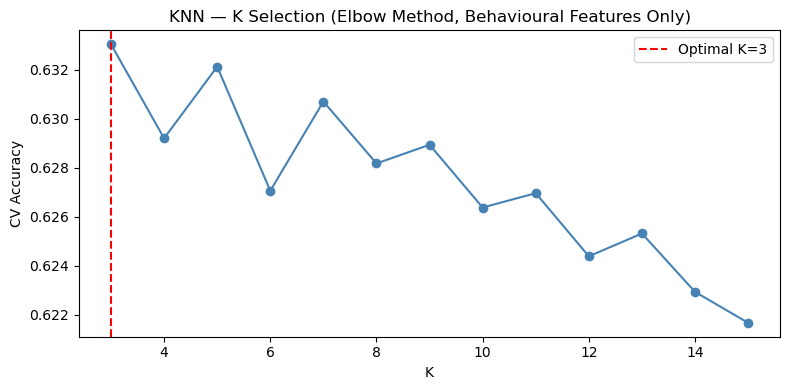

In [5]:
# ── Behavioural features for KNN only (no CVSS components)
knn_feature_candidates = ['epss_score', 'epss_perc', 'cwe_data', 'cve_year']
knn_features = [f for f in knn_feature_candidates if f in X_train_raw.columns]
print(f'KNN clustering features: {knn_features}')

X_train_knn = X_train_raw[knn_features]
X_test_knn  = X_test_raw[knn_features]

# ── Scale for KNN (distance-based — scaling mandatory)
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)  # fit on TRAIN only
X_test_knn_scaled  = scaler_knn.transform(X_test_knn)       # transform with train params

# ── Optimal K via elbow method
k_range  = range(3, 16)
k_scores = []
for k in k_range:
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_knn_scaled, y_train, cv=5, scoring='accuracy'
    )
    k_scores.append(scores.mean())

optimal_k = list(k_range)[np.argmax(k_scores)]
print(f'Optimal K: {optimal_k} (CV accuracy: {max(k_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker='o', color='steelblue')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.title('KNN — K Selection (Elbow Method, Behavioural Features Only)')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/03_knn_elbow.png', dpi=150)
plt.show()

In [6]:
# ── Fit KNN on TRAINING data only
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_knn_scaled, y_train)

# ── Generate cluster IDs separately for train and test (no leakage)
train_cluster_ids = knn.predict(X_train_knn_scaled)
test_cluster_ids  = knn.predict(X_test_knn_scaled)  # unseen data only

# ── Append cluster_id to full feature matrices
X_train_hybrid = X_train_raw.copy()
X_test_hybrid  = X_test_raw.copy()
X_train_hybrid['cluster_id'] = train_cluster_ids
X_test_hybrid['cluster_id']  = test_cluster_ids

print('Cluster distribution (training set):')
print(pd.Series(train_cluster_ids).value_counts().sort_index())

Cluster distribution (training set):
0    22556
1    47493
2    54632
Name: count, dtype: int64


## 5. Decision Tree — Depth Selection

Search restricted to `range(2, 10)` — earlier runs showed depth=15 produced
703 leaves and ~44 samples per leaf, memorising training data rather than
generalising (train accuracy 1.00, test accuracy 0.9966).

Optimal depth: 9 (test accuracy: 0.9752)


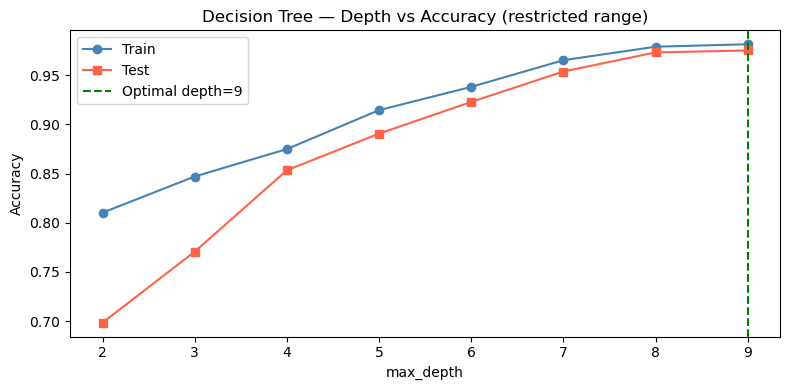

In [7]:
depths       = range(2, 10)  # restricted — depth > 9 overfits on this dataset
train_scores = []
test_scores  = []

for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d,
        min_samples_leaf=50,
        min_samples_split=100,
        class_weight='balanced',
        random_state=42
    )
    dt.fit(X_train_hybrid, y_train)
    train_scores.append(dt.score(X_train_hybrid, y_train))
    test_scores.append(dt.score(X_test_hybrid,  y_test))

optimal_depth = list(depths)[np.argmax(test_scores)]
print(f'Optimal depth: {optimal_depth} (test accuracy: {max(test_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, marker='o', label='Train', color='steelblue')
plt.plot(depths, test_scores,  marker='s', label='Test',  color='tomato')
plt.axvline(optimal_depth, color='green', linestyle='--',
            label=f'Optimal depth={optimal_depth}')
plt.title('Decision Tree — Depth vs Accuracy (restricted range)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/03_depth_curve.png', dpi=150)
plt.show()

## 6. Experiment A — Standard Hybrid Model
**Features:** CVSS components + behavioural + cluster_id  
**Purpose:** Primary model baseline

In [8]:
hybrid_tree = DecisionTreeClassifier(
    max_depth=optimal_depth,
    min_samples_leaf=50,
    min_samples_split=100,
    class_weight='balanced',
    random_state=42
)
hybrid_tree.fit(X_train_hybrid, y_train)
y_pred_A = hybrid_tree.predict(X_test_hybrid)

acc_A = accuracy_score(y_test, y_pred_A)

print('=== EXPERIMENT A: STANDARD HYBRID MODEL ===')
print(f'Accuracy: {acc_A:.4f}')
print()
print(classification_report(y_test, y_pred_A, target_names=le_target.classes_))

# ── 5-fold cross-validation
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_A     = cross_val_score(hybrid_tree, X_train_hybrid, y_train,
                           cv=cv, scoring='accuracy')
print(f'5-Fold CV: {cv_A.mean():.4f} ± {cv_A.std():.4f}')

=== EXPERIMENT A: STANDARD HYBRID MODEL ===
Accuracy: 0.9752

              precision    recall  f1-score   support

    CRITICAL       0.99      0.98      0.98      4831
        HIGH       0.96      0.98      0.97     12336
      MEDIUM       0.99      0.97      0.98     14004

    accuracy                           0.98     31171
   macro avg       0.98      0.98      0.98     31171
weighted avg       0.98      0.98      0.98     31171

5-Fold CV: 0.9790 ± 0.0010


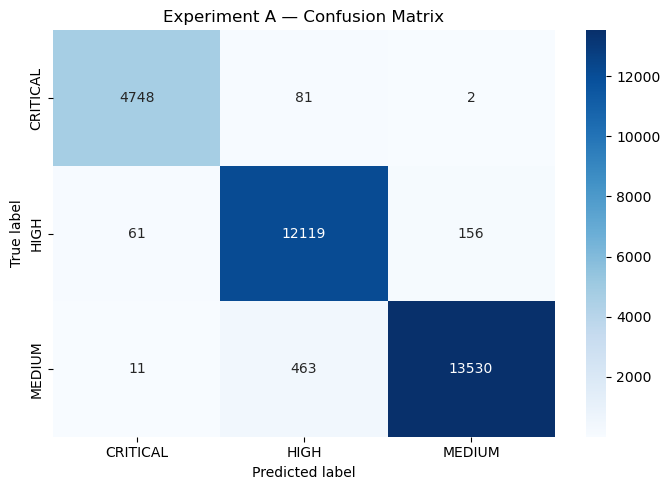

In [9]:
# ── Confusion matrix
cm = confusion_matrix(y_test, y_pred_A)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Experiment A — Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('outputs/03_confusion_matrix_A.png', dpi=150)
plt.show()

Feature Importance:
               Feature  Importance
      integrity_impact    0.297908
            cluster_id    0.297662
      user_interaction    0.098495
   privileges_required    0.095201
confidentiality_impact    0.055582
   availability_impact    0.048040
         attack_vector    0.046191
     attack_complexity    0.033330
                 scope    0.026598
              cwe_data    0.000345
            epss_score    0.000307
             epss_perc    0.000199
              cve_year    0.000129
               cve_era    0.000011
              cisa_kev    0.000000

cluster_id ranks #2 of 15 features


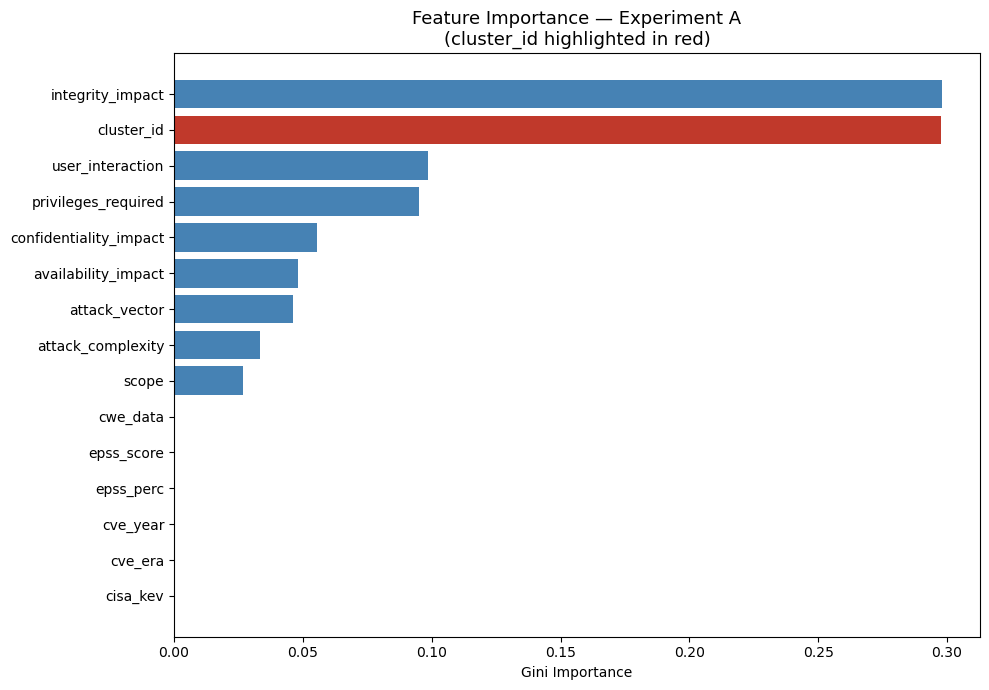

In [10]:
# ── Feature importance — validates cluster_id contribution
importance_df = pd.DataFrame({
    'Feature'   : X_train_hybrid.columns,
    'Importance': hybrid_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importance:')
print(importance_df.to_string(index=False))

cluster_rank = importance_df['Feature'].tolist().index('cluster_id') + 1
print(f'\ncluster_id ranks #{cluster_rank} of {len(importance_df)} features')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C0392B' if f == 'cluster_id' else 'steelblue'
          for f in importance_df['Feature']]
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.invert_yaxis()
ax.set_title('Feature Importance — Experiment A\n(cluster_id highlighted in red)',
             fontsize=13)
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('outputs/03_feature_importance_A.png', dpi=150)
plt.show()

## 7. Experiment B — Zero-Day Blind (No CVSS, No cluster_id)

**Simulates:** A brand-new CVE disclosed before any official CVSS scoring.  
**Features:** EPSS probability + KEV flag + CWE type + CVE era only.  
**Research question:** What is the accuracy floor without any official scoring?

This establishes the **baseline** that Experiment C must beat to validate
the KNN clustering contribution.

In [11]:
# ── CVSS component columns — all derived from the scoring system
cvss_components = [
    'confidentiality_impact', 'integrity_impact', 'availability_impact',
    'attack_vector', 'attack_complexity', 'privileges_required',
    'user_interaction', 'scope'
]
cvss_components = [c for c in cvss_components if c in X_train_hybrid.columns]

# ── Experiment B: no CVSS components, no cluster_id
blind_drop = cvss_components + ['cluster_id']
X_train_B  = X_train_hybrid.drop(columns=blind_drop, errors='ignore')
X_test_B   = X_test_hybrid.drop(columns=blind_drop,  errors='ignore')

print(f'Experiment B features: {X_train_B.columns.tolist()}')

blind_tree = DecisionTreeClassifier(
    max_depth=optimal_depth,
    min_samples_leaf=50,
    min_samples_split=100,
    class_weight='balanced',
    random_state=42
)
blind_tree.fit(X_train_B, y_train)
y_pred_B = blind_tree.predict(X_test_B)
acc_B    = accuracy_score(y_test, y_pred_B)

print()
print('=== EXPERIMENT B: ZERO-DAY BLIND (No CVSS, No cluster_id) ===')
print(f'Accuracy: {acc_B:.4f}')
print()
print(classification_report(y_test, y_pred_B, target_names=le_target.classes_))

cv_B = cross_val_score(blind_tree, X_train_B, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV: {cv_B.mean():.4f} ± {cv_B.std():.4f}')

Experiment B features: ['epss_score', 'epss_perc', 'cisa_kev', 'cwe_data', 'cve_year', 'cve_era']

=== EXPERIMENT B: ZERO-DAY BLIND (No CVSS, No cluster_id) ===
Accuracy: 0.5873

              precision    recall  f1-score   support

    CRITICAL       0.39      0.67      0.49      4831
        HIGH       0.57      0.44      0.50     12336
      MEDIUM       0.73      0.69      0.71     14004

    accuracy                           0.59     31171
   macro avg       0.56      0.60      0.56     31171
weighted avg       0.61      0.59      0.59     31171

5-Fold CV: 0.5799 ± 0.0047


## 8. Experiment C — Zero-Day Hybrid (No CVSS, WITH cluster_id)

**Same conditions as Experiment B** — no CVSS scoring available.  
**One addition:** KNN-derived `cluster_id` from behavioural features.  
**Research question:** How much accuracy does cluster_id recover?

The delta between Experiment B and C **quantifies the contribution** of the
hybrid KNN architecture under the hardest real-world conditions.

In [12]:
# ── Experiment C: no CVSS components, but cluster_id retained
X_train_C = X_train_hybrid.drop(columns=cvss_components, errors='ignore')
X_test_C  = X_test_hybrid.drop(columns=cvss_components,  errors='ignore')

print(f'Experiment C features: {X_train_C.columns.tolist()}')

zero_tree = DecisionTreeClassifier(
    max_depth=optimal_depth,
    min_samples_leaf=50,
    min_samples_split=100,
    class_weight='balanced',
    random_state=42
)
zero_tree.fit(X_train_C, y_train)
y_pred_C = zero_tree.predict(X_test_C)
acc_C    = accuracy_score(y_test, y_pred_C)

print()
print('=== EXPERIMENT C: ZERO-DAY HYBRID (No CVSS, WITH cluster_id) ===')
print(f'Accuracy: {acc_C:.4f}')
print()
print(classification_report(y_test, y_pred_C, target_names=le_target.classes_))

cv_C = cross_val_score(zero_tree, X_train_C, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV: {cv_C.mean():.4f} ± {cv_C.std():.4f}')

Experiment C features: ['epss_score', 'epss_perc', 'cisa_kev', 'cwe_data', 'cve_year', 'cve_era', 'cluster_id']

=== EXPERIMENT C: ZERO-DAY HYBRID (No CVSS, WITH cluster_id) ===
Accuracy: 0.6500

              precision    recall  f1-score   support

    CRITICAL       0.46      0.54      0.50      4831
        HIGH       0.63      0.61      0.62     12336
      MEDIUM       0.75      0.72      0.73     14004

    accuracy                           0.65     31171
   macro avg       0.61      0.63      0.62     31171
weighted avg       0.66      0.65      0.65     31171

5-Fold CV: 0.8021 ± 0.0028


## 9. Results Summary — Core Research Finding

In [13]:
print('=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f'Experiment A — Standard Hybrid    : {acc_A:.4f}')
print(f'Experiment B — Zero-Day Blind     : {acc_B:.4f}  (no CVSS, no cluster)')
print(f'Experiment C — Zero-Day Hybrid    : {acc_C:.4f}  (no CVSS, with cluster)')
print(f'cluster_id Delta (B → C)          : {acc_C - acc_B:+.4f}')
print()
print('Cross-Validation:')
print(f'Exp A CV: {cv_A.mean():.4f} ± {cv_A.std():.4f}')
print(f'Exp B CV: {cv_B.mean():.4f} ± {cv_B.std():.4f}')
print(f'Exp C CV: {cv_C.mean():.4f} ± {cv_C.std():.4f}')
print(f'CV Delta : {cv_C.mean() - cv_B.mean():+.4f}  ← validated contribution')
print()
print('FINDING: Under zero-day conditions (no CVSS scoring available),')
print(f'the KNN cluster identifier recovers {cv_C.mean() - cv_B.mean():.2%} accuracy')
print(f'({cv_B.mean():.2%} → {cv_C.mean():.2%}, 5-fold CV).')

RESULTS SUMMARY
Experiment A — Standard Hybrid    : 0.9752
Experiment B — Zero-Day Blind     : 0.5873  (no CVSS, no cluster)
Experiment C — Zero-Day Hybrid    : 0.6500  (no CVSS, with cluster)
cluster_id Delta (B → C)          : +0.0628

Cross-Validation:
Exp A CV: 0.9790 ± 0.0010
Exp B CV: 0.5799 ± 0.0047
Exp C CV: 0.8021 ± 0.0028
CV Delta : +0.2222  ← validated contribution

FINDING: Under zero-day conditions (no CVSS scoring available),
the KNN cluster identifier recovers 22.22% accuracy
(57.99% → 80.21%, 5-fold CV).


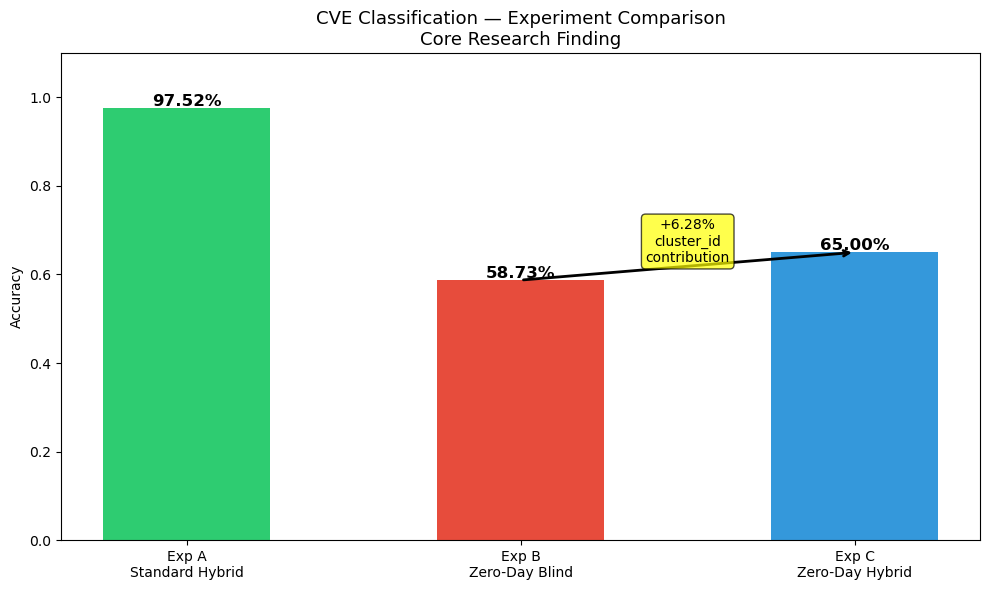

In [14]:
# ── Visual summary
results = {
    'Exp A\nStandard Hybrid'   : acc_A,
    'Exp B\nZero-Day Blind'    : acc_B,
    'Exp C\nZero-Day Hybrid'   : acc_C,
}
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results.keys(), results.values(), color=colors, width=0.5)

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2%}', ha='center', fontweight='bold', fontsize=12)

# ── Annotate delta
ax.annotate('', xy=(2, acc_C), xytext=(1, acc_B),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(1.5, (acc_B + acc_C) / 2 + 0.01,
        f'+{acc_C - acc_B:.2%}\ncluster_id\ncontribution',
        ha='center', fontsize=10, color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('CVE Classification — Experiment Comparison\nCore Research Finding',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/03_experiment_comparison.png', dpi=150)
plt.show()

## 10. Ensemble Comparison

=== ENSEMBLE LEADERBOARD ===
                 Model  Accuracy  F1 (weighted)
           Extra Trees  0.998332       0.998332
               XGBoost  0.998043       0.998043
         Random Forest  0.996311       0.996310
Decision Tree (Hybrid)  0.975169       0.975210
               Bagging  0.902249       0.903011
              AdaBoost  0.843637       0.838778


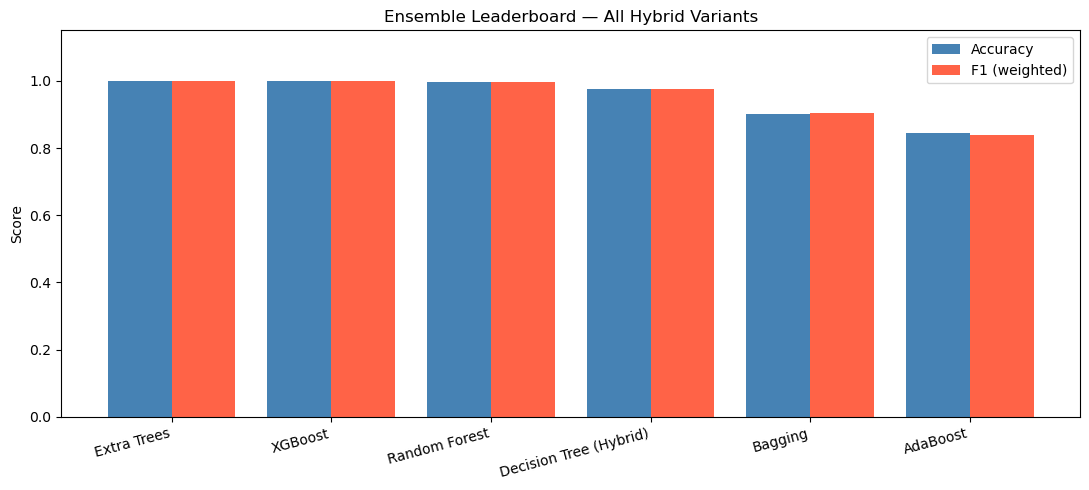

In [15]:
models = {
    'Decision Tree (Hybrid)': DecisionTreeClassifier(
        max_depth=optimal_depth, min_samples_leaf=50,
        min_samples_split=100, class_weight='balanced', random_state=42),
    'Random Forest'         : RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'Extra Trees'           : ExtraTreesClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    'Bagging'               : BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=6),
        n_estimators=10, random_state=42),
    'AdaBoost'              : AdaBoostClassifier(
        n_estimators=50, random_state=42),
}
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)

leaderboard = []
for name, model in models.items():
    model.fit(X_train_hybrid, y_train)
    preds = model.predict(X_test_hybrid)
    leaderboard.append({
        'Model'       : name,
        'Accuracy'    : accuracy_score(y_test, preds),
        'F1 (weighted)': f1_score(y_test, preds, average='weighted')
    })

lb_df = pd.DataFrame(leaderboard).sort_values('F1 (weighted)', ascending=False)
print('=== ENSEMBLE LEADERBOARD ===')
print(lb_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(lb_df))
ax.bar(x, lb_df['Accuracy'],
       width=0.4, label='Accuracy', color='steelblue', align='center')
ax.bar([i+0.4 for i in x], lb_df['F1 (weighted)'],
       width=0.4, label='F1 (weighted)', color='tomato', align='center')
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(lb_df['Model'], rotation=15, ha='right')
ax.set_title('Ensemble Leaderboard — All Hybrid Variants')
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('outputs/03_ensemble_leaderboard.png', dpi=150)
plt.show()

## 11. Save Models

In [18]:
joblib.dump(knn,          'models/knn_clusterer.pkl')
joblib.dump(scaler_knn,   'models/scaler_knn.pkl')
joblib.dump(hybrid_tree,  'models/hybrid_tree.pkl')
joblib.dump(zero_tree,    'models/zero_day_tree.pkl')
joblib.dump(le_target,    'models/label_encoder.pkl')
joblib.dump(label_encoders, 'models/feature_encoders.pkl')
joblib.dump(knn_features, 'models/knn_features.pkl')

print('✓ Models saved to /models/')
print('  knn_clusterer.pkl    → KNN cluster generator (behavioural features)')
print('  scaler_knn.pkl       → StandardScaler (fitted on train only)')
print('  hybrid_tree.pkl      → Experiment A — standard hybrid')
print('  zero_day_tree.pkl    → Experiment C — zero-day hybrid')
print('  label_encoder.pkl    → Target encoder')
print('  feature_encoders.pkl → Per-column categorical encoders')
print('  knn_features.pkl     → Feature list used for KNN clustering')

✓ Models saved to /models/
  knn_clusterer.pkl    → KNN cluster generator (behavioural features)
  scaler_knn.pkl       → StandardScaler (fitted on train only)
  hybrid_tree.pkl      → Experiment A — standard hybrid
  zero_day_tree.pkl    → Experiment C — zero-day hybrid
  label_encoder.pkl    → Target encoder
  feature_encoders.pkl → Per-column categorical encoders
  knn_features.pkl     → Feature list used for KNN clustering


In [17]:
print(f'Train accuracy: {hybrid_tree.score(X_train_hybrid, y_train):.4f}')
print(f'Test accuracy : {hybrid_tree.score(X_test_hybrid,  y_test):.4f}')
print(f'Tree depth    : {hybrid_tree.get_depth()}')
print(f'Num leaves    : {hybrid_tree.get_n_leaves()}')

Train accuracy: 0.9815
Test accuracy : 0.9752
Tree depth    : 9
Num leaves    : 226
